# Genome Assembly Simulation using De Bruijn Graph

## Objective
This project simulates genome assembly using the De Bruijn Graph approach. It demonstrates how short DNA reads can be reconstructed into longer sequences (contigs) by identifying overlaps between k-mers.

## Concepts Covered
- k-mer generation
- Graph construction (prefix → suffix)
- De Bruijn Graph representation
- Eulerian path traversal
- Contig assembly
- Graph visualization

## Methodology
1. Input DNA reads
2. Break reads into k-mers
3. Construct directed graph:
   - Nodes = (k-1)-mers
   - Edges = k-mers
4. Find Eulerian path
5. Reconstruct sequence (contig)
6. Visualize graph

## Key Insight
Genome assembly relies on reconstructing sequences from overlaps. The De Bruijn Graph converts this problem into a graph traversal problem.

## Tools Used
- Python
- NetworkX
- Matplotlib

K-mers:
['ATG', 'TGC', 'GCG', 'GCA', 'CAT', 'ATG', 'CAT', 'ATG', 'TGC', 'AGG', 'GGC', 'GCA', 'GGC', 'GCA', 'CAT']

Graph:
AT -> ['TG', 'TG', 'TG']
TG -> ['GC', 'GC']
GC -> ['CG', 'CA', 'CA', 'CA']
CA -> ['AT', 'AT', 'AT']
AG -> ['GG']
GG -> ['GC', 'GC']

Eulerian Path:
['AG', 'GG', 'GC', 'GC', 'CA', 'AT', 'TG', 'GC', 'CA', 'AT', 'TG', 'GC', 'CG', 'CA', 'AT', 'TG']

Assembled Sequence:
AGGCCATGCATGCGATG


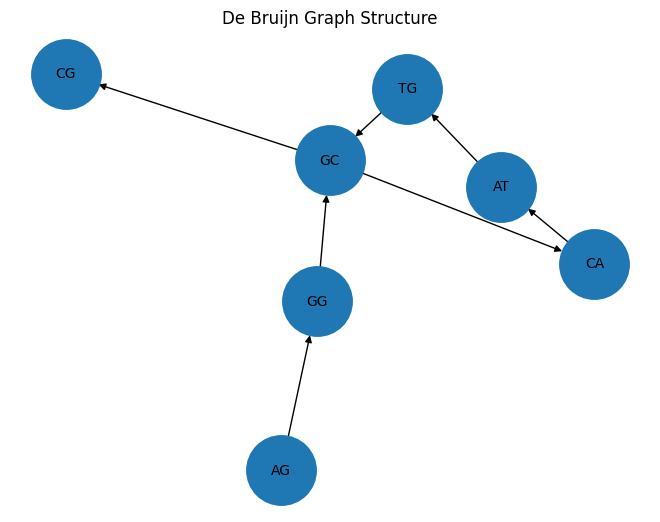

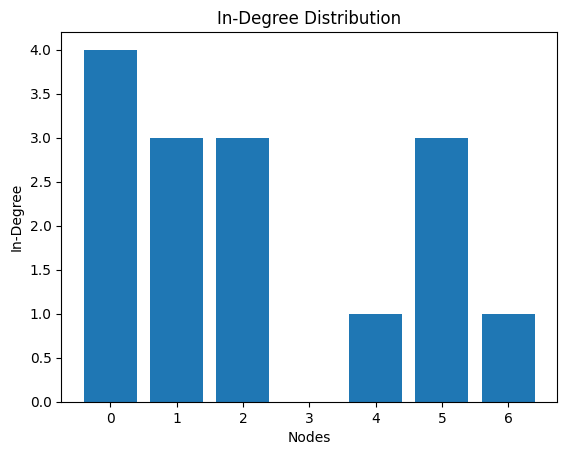

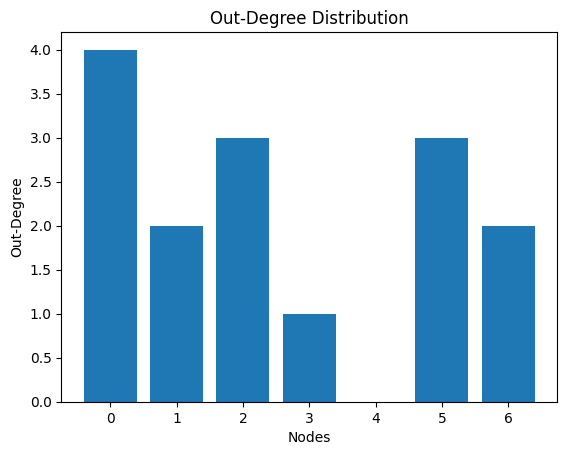

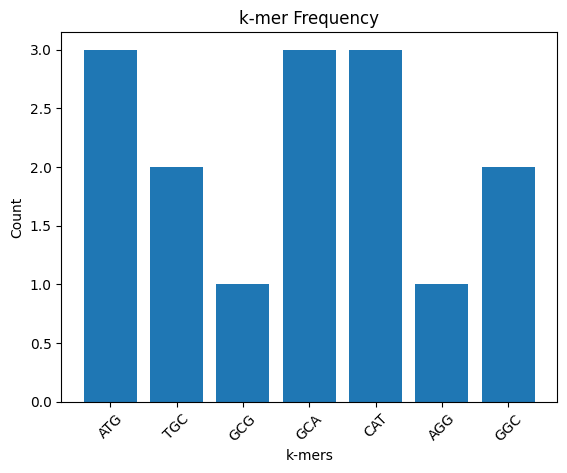

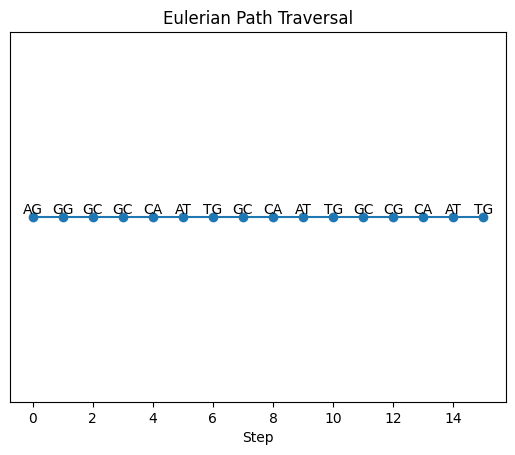


Contig Length: 17


In [2]:
# Import libraries
from collections import defaultdict, Counter
import networkx as nx
import matplotlib.pyplot as plt

# Input reads
reads = [
    "ATGCG",
    "GCATG",
    "CATGC",
    "AGGCA",
    "GGCAT"
]

# Step 1: Generate k-mers
def get_kmers(reads, k):
    kmers = []
    for read in reads:
        for i in range(len(read) - k + 1):
            kmers.append(read[i:i+k])
    return kmers

# Step 2: Build De Bruijn Graph
def build_debruijn_graph(kmers):
    graph = defaultdict(list)
    in_degree = Counter()
    out_degree = Counter()

    for kmer in kmers:
        prefix = kmer[:-1]
        suffix = kmer[1:]

        graph[prefix].append(suffix)
        out_degree[prefix] += 1
        in_degree[suffix] += 1

    return graph, in_degree, out_degree

# Step 3: Eulerian Path
def find_start_node(graph, in_degree, out_degree):
    for node in graph:
        if out_degree[node] > in_degree[node]:
            return node
    return list(graph.keys())[0]

def eulerian_path(graph, in_degree, out_degree):
    graph_copy = {node: edges[:] for node, edges in graph.items()}

    start = find_start_node(graph_copy, in_degree, out_degree)
    stack = [start]
    path = []

    while stack:
        current = stack[-1]
        if current in graph_copy and graph_copy[current]:
            next_node = graph_copy[current].pop()
            stack.append(next_node)
        else:
            path.append(stack.pop())

    return path[::-1]

# Step 4: Assemble sequence
def assemble_sequence(path):
    sequence = path[0]
    for node in path[1:]:
        sequence += node[-1]
    return sequence

# Step 5: Graph Visualization (Improved)
def visualize_graph(graph):
    G = nx.DiGraph()

    for node in graph:
        for neighbor in graph[node]:
            G.add_edge(node, neighbor)

    pos = nx.spring_layout(G, seed=42)

    plt.figure()
    nx.draw(G, pos, with_labels=True, node_size=2500, font_size=10)
    plt.title("De Bruijn Graph Structure")
    plt.show()

# Step 6: Degree Distribution Plot
def plot_degree_distribution(in_degree, out_degree):
    nodes = list(set(list(in_degree.keys()) + list(out_degree.keys())))

    in_vals = [in_degree[n] for n in nodes]
    out_vals = [out_degree[n] for n in nodes]

    plt.figure()
    plt.bar(range(len(nodes)), in_vals)
    plt.title("In-Degree Distribution")
    plt.xlabel("Nodes")
    plt.ylabel("In-Degree")
    plt.show()

    plt.figure()
    plt.bar(range(len(nodes)), out_vals)
    plt.title("Out-Degree Distribution")
    plt.xlabel("Nodes")
    plt.ylabel("Out-Degree")
    plt.show()

# Step 7: k-mer Frequency Plot
def plot_kmer_frequency(kmers):
    freq = Counter(kmers)

    labels = list(freq.keys())
    values = list(freq.values())

    plt.figure()
    plt.bar(range(len(labels)), values)
    plt.title("k-mer Frequency")
    plt.xlabel("k-mers")
    plt.ylabel("Count")
    plt.xticks(range(len(labels)), labels, rotation=45)
    plt.show()

# Step 8: Path Visualization (Linear)
def plot_path(path):
    y = [1] * len(path)

    plt.figure()
    plt.plot(range(len(path)), y, marker='o')

    for i, node in enumerate(path):
        plt.text(i, 1, node, ha='center', va='bottom')

    plt.title("Eulerian Path Traversal")
    plt.xlabel("Step")
    plt.yticks([])
    plt.show()

# Run pipeline
k = 3
kmers = get_kmers(reads, k)

print("K-mers:")
print(kmers)

graph, in_degree, out_degree = build_debruijn_graph(kmers)

print("\nGraph:")
for node in graph:
    print(f"{node} -> {graph[node]}")

path = eulerian_path(graph, in_degree, out_degree)

print("\nEulerian Path:")
print(path)

contig = assemble_sequence(path)

print("\nAssembled Sequence:")
print(contig)

# Visualizations
visualize_graph(graph)
plot_degree_distribution(in_degree, out_degree)
plot_kmer_frequency(kmers)
plot_path(path)

# Contig Insight
print("\nContig Length:", len(contig))